# **Credit Card Lending Prediction Model**

**Objective**

The objective of this notebook is to predict Credit Card Lending using UK macroeconomic and retail banking variables. Feature engineering and normalization are performed before model training, and three regression models are compared: Linear Regression, Random Forest and XGBoost.

**Import Libraries**

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import statsmodels.api as sm

**Load Dataset**

In [2]:
df = pd.read_csv("FINAL_DS.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)
df.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending
0,2008-01-01,2008,January,5.50,2.2,5.2,65.6,0.4,33417,224159,71326,101598,54232
1,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375
2,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471
3,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404
4,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211


**Feature Engineering**

In [3]:
# Create lag features for Credit Card Lending
df["CreditCard_Lag1"] = df["Credit_Card_Lending"].shift(1)

# Remove rows with missing lag values
df_model = df.dropna().reset_index(drop=True)

# Display the first five rows
df_model.head()

,Date,Year,Month,Bank_Rate,CPI,Unemployment_Rate,House_Price_Index,GDP_Growth,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,CreditCard_Lag1
0,2008-02-01,2008,February,5.25,2.5,5.2,65.0,0.4,31492,226772,71064,102081,54375,54232.0
1,2008-03-01,2008,March,5.25,2.5,5.3,64.5,0.4,32823,227769,60454,101945,54471,54375.0
2,2008-04-01,2008,April,5.00,3.0,5.2,64.7,-0.5,31895,233766,57134,101756,54404,54471.0
3,2008-05-01,2008,May,5.00,3.3,5.4,65.1,-0.5,32210,237820,40546,101556,55211,54404.0
4,2008-06-01,2008,June,5.00,3.8,5.5,64.2,-0.5,33348,241184,35391,100691,54955,55211.0


**Feature Selection**

In [4]:
features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "CreditCard_Lag1"
]

# Create modelling dataframe and remove rows with missing lag values
df_model = df[features + ["Credit_Card_Lending"]].dropna().reset_index(drop=True)

X = df_model[features]
y = df_model["Credit_Card_Lending"]

print(X.shape, y.shape)

(215, 5) (215,)


**Correlation Analysis**

In [5]:
# Correlation matrix
corr_matrix = df_model[features + ["Credit_Card_Lending"]].corr()

# Display correlation with the target variable
cc_corr = corr_matrix["Credit_Card_Lending"].sort_values(ascending=False)

cc_corr

Credit_Card_Lending    1.000000
CreditCard_Lag1        0.981533
Bank_Rate              0.166978
Unemployment_Rate      0.064753
GDP_Growth            -0.117140
CPI                   -0.185490
Name: Credit_Card_Lending, dtype: float64

**Multicollinearity Analysis (VIF)**

In [6]:
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
4,CreditCard_Lag1,17.783325
3,Unemployment_Rate,14.770662
1,CPI,2.965551
0,Bank_Rate,2.229035
2,GDP_Growth,1.014721


**Chronological Train/Test Split**

In [7]:
split = int(len(df_model) * 0.8)

train = df_model.iloc[:split]
test = df_model.iloc[split:]

X_train = train[features]
X_test = test[features]

y_train = train["Credit_Card_Lending"]
y_test = test["Credit_Card_Lending"]

print(X_train.shape, X_test.shape)

(172, 5) (43, 5)


**Standardize Features**

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_test_scaled.shape)

(172, 5) (43, 5)


**Linear Regression Model**

In [9]:
# Train the Linear Regression model
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

# Generate predictions
y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


**Linear Regression Evaluation**

In [10]:
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results")
print("R² Score :", round(lr_r2, 4))
print("MAE      :", round(lr_mae, 2))
print("RMSE     :", round(lr_rmse, 2))

Linear Regression Results
R² Score : 0.9959
MAE      : 196.9
RMSE     : 236.07


**Ordinary Least Squares (OLS) Regression**

In [11]:
# Add intercept term
X_train_sm = sm.add_constant(X_train_scaled)

# Fit OLS model
ols_model = sm.OLS(y_train, X_train_sm).fit()

# Display statistical summary
print(ols_model.summary())

                             OLS Regression Results                            
Dep. Variable:     Credit_Card_Lending   R-squared:                       0.962
Model:                             OLS   Adj. R-squared:                  0.961
Method:                  Least Squares   F-statistic:                     839.9
Date:                 Wed, 19 Aug 2026   Prob (F-statistic):          7.72e-116
Time:                         02:03:30   Log-Likelihood:                -1413.9
No. Observations:                  172   AIC:                             2840.
Df Residuals:                      166   BIC:                             2859.
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.083e+04     69.778    728.47

**Actual vs Predicted Credit Card Lending**

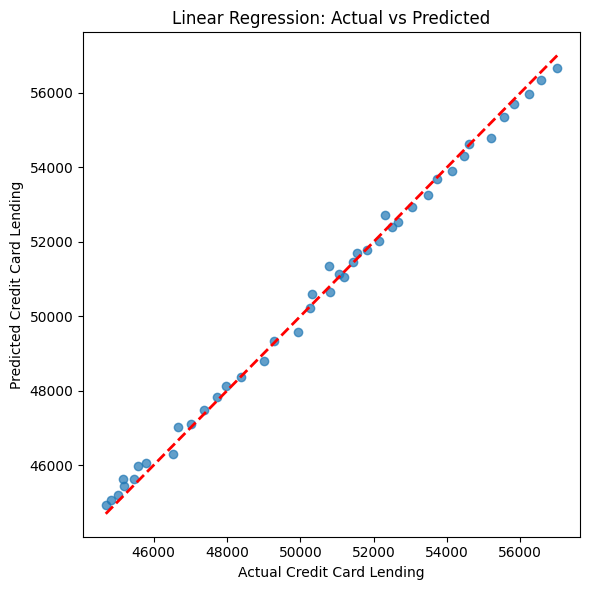

In [12]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lr, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Credit Card Lending")
plt.ylabel("Predicted Credit Card Lending")
plt.title("Linear Regression: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

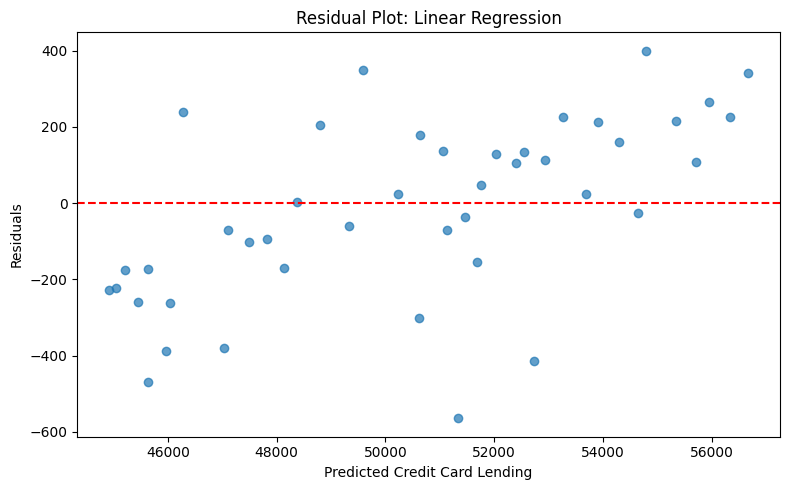

In [13]:
# Calculate residuals
residuals = y_test - y_pred_lr

plt.figure(figsize=(8,5))

plt.scatter(y_pred_lr, residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Credit Card Lending")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")
plt.tight_layout()
plt.show()

**Random Forest Regression**

In [14]:
# Train the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Generate predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


**Random Forest Feature Importance**

In [15]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
4,CreditCard_Lag1,0.980066
3,Unemployment_Rate,0.006928
2,GDP_Growth,0.005008
1,CPI,0.004832
0,Bank_Rate,0.003167


**Random Forest Evaluation**

In [16]:
rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest Results")
print("R² Score :", round(rf_r2, 4))
print("MAE      :", round(rf_mae, 2))
print("RMSE     :", round(rf_rmse, 2))

Random Forest Results
R² Score : 0.9752
MAE      : 431.18
RMSE     : 578.28


**Actual vs Predicted Credit Card Lending**

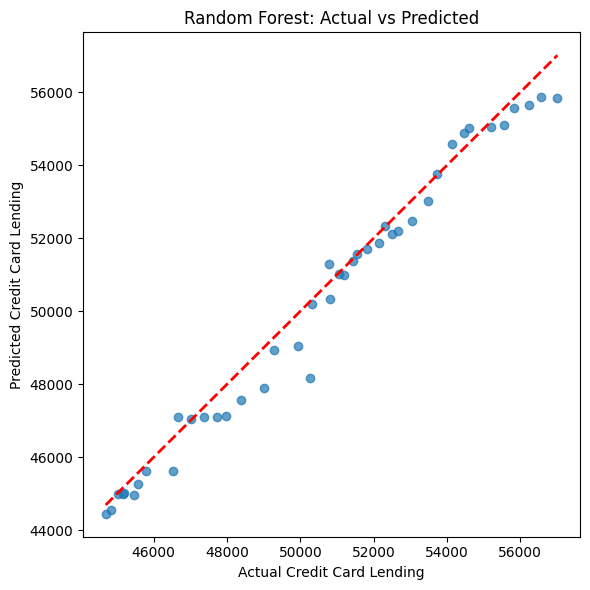

In [17]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Credit Card Lending")
plt.ylabel("Predicted Credit Card Lending")
plt.title("Random Forest: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

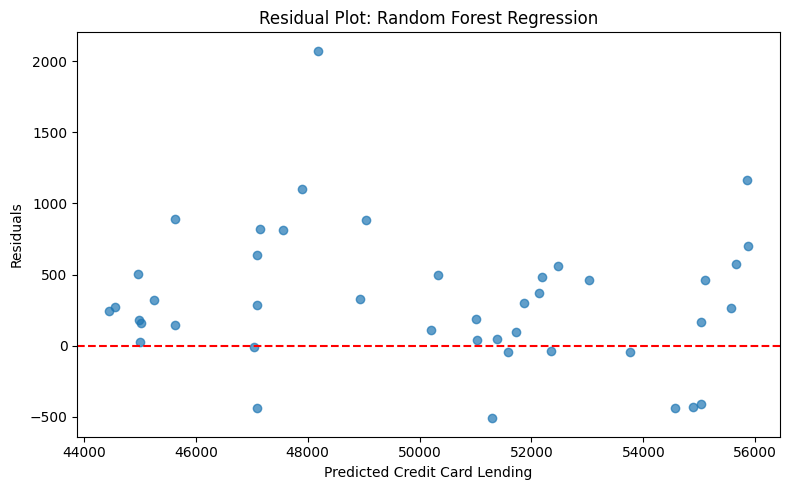

In [18]:
# Calculate residuals
rf_residuals = y_test - y_pred_rf

plt.figure(figsize=(8,5))

plt.scatter(y_pred_rf, rf_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Credit Card Lending")
plt.ylabel("Residuals")
plt.title("Residual Plot: Random Forest Regression")
plt.tight_layout()
plt.show()

**XGBoost Regression**

In [19]:
# Train the XGBoost model
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Generate predictions
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


**XGBoost Feature Importance**

In [20]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="Importance", ascending=False)

xgb_importance

,Feature,Importance
4,CreditCard_Lag1,0.644622
0,Bank_Rate,0.226173
3,Unemployment_Rate,0.055516
1,CPI,0.046711
2,GDP_Growth,0.026978


**XGBoost Evaluation**

In [21]:
xgb_r2 = r2_score(y_test, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost Results")
print("R² Score :", round(xgb_r2, 4))
print("MAE      :", round(xgb_mae, 2))
print("RMSE     :", round(xgb_rmse, 2))

XGBoost Results
R² Score : 0.9692
MAE      : 525.31
RMSE     : 644.31


**Actual vs Predicted Credit Card Lending**

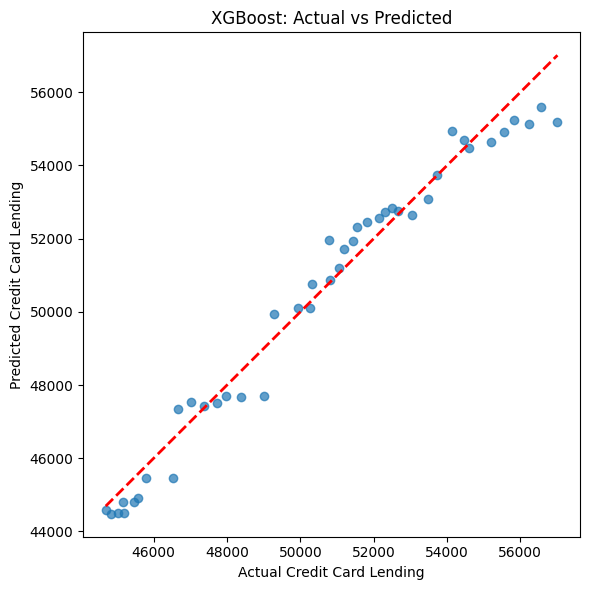

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.7)

# 45-degree reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    linewidth=2
)

plt.xlabel("Actual Credit Card Lending")
plt.ylabel("Predicted Credit Card Lending")
plt.title("XGBoost: Actual vs Predicted")
plt.tight_layout()
plt.show()

**Residual Analysis**

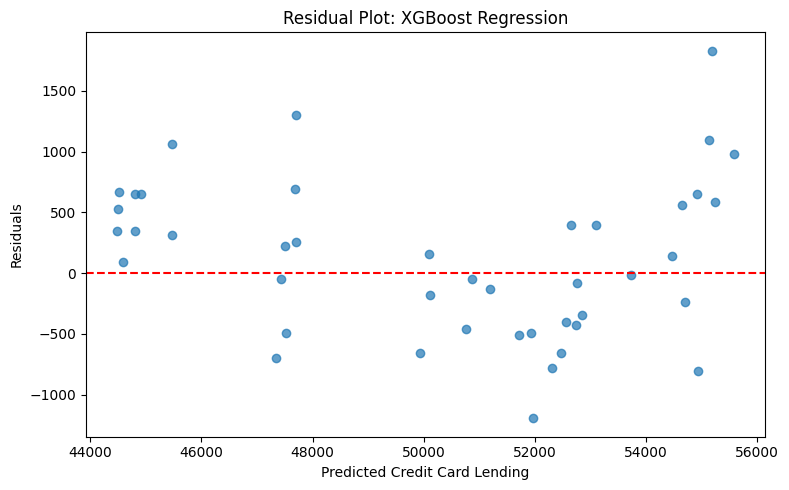

In [23]:
# Calculate residuals
xgb_residuals = y_test - y_pred_xgb

plt.figure(figsize=(8,5))

plt.scatter(y_pred_xgb, xgb_residuals, alpha=0.7)

plt.axhline(0, color="red", linestyle="--")

plt.xlabel("Predicted Credit Card Lending")
plt.ylabel("Residuals")
plt.title("Residual Plot: XGBoost Regression")
plt.tight_layout()
plt.show()

**Model Comparison**

In [24]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "R²": [lr_r2, rf_r2, xgb_r2],
    "MAE": [lr_mae, rf_mae, xgb_mae],
    "RMSE": [lr_rmse, rf_rmse, xgb_rmse]
})

comparison = comparison.sort_values(by="R²", ascending=False)

comparison

,Model,R²,MAE,RMSE
0,Linear Regression,0.995859,196.900557,236.065304
1,Random Forest,0.975152,431.181520,578.277658
2,XGBoost,0.969153,525.308655,644.306337


**Model Comparison Visualization**

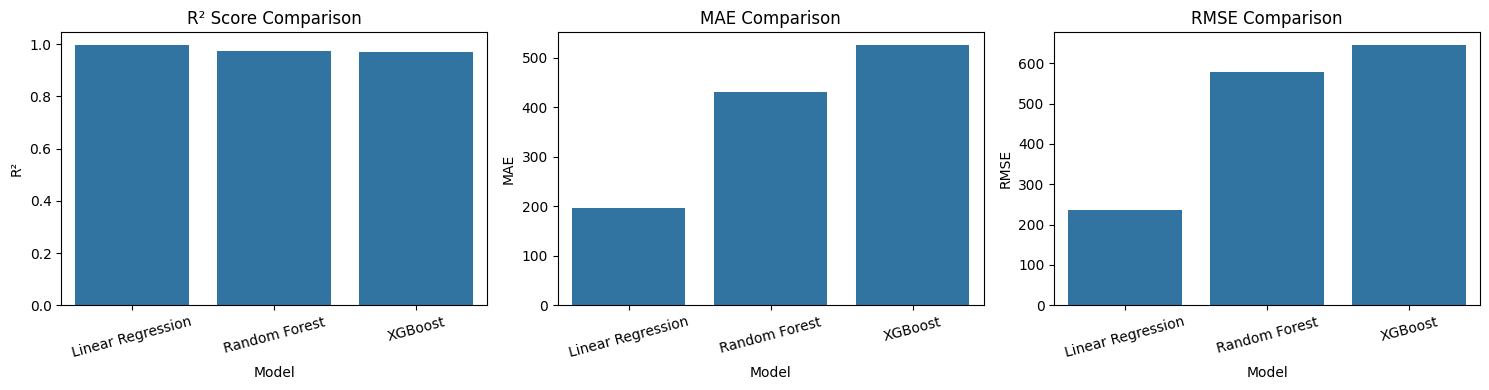

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# R²
sns.barplot(
    data=comparison,
    x="Model",
    y="R²",
    ax=axes[0]
)
axes[0].set_title("R² Score Comparison")
axes[0].tick_params(axis="x", rotation=15)

# MAE
sns.barplot(
    data=comparison,
    x="Model",
    y="MAE",
    ax=axes[1]
)
axes[1].set_title("MAE Comparison")
axes[1].tick_params(axis="x", rotation=15)

# RMSE
sns.barplot(
    data=comparison,
    x="Model",
    y="RMSE",
    ax=axes[2]
)
axes[2].set_title("RMSE Comparison")
axes[2].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [26]:
import joblib
import os

os.makedirs("../synthetic_bank/models", exist_ok=True)

In [27]:
joblib.dump(
    lr_model,
    "../synthetic_bank/models/credit_card_lr.pkl"
)

['../synthetic_bank/models/credit_card_lr.pkl']

In [28]:
joblib.dump(
    scaler,
    "../synthetic_bank/models/credit_card_scaler.pkl"
)

['../synthetic_bank/models/credit_card_scaler.pkl']

In [29]:
credit_card_features = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "CreditCard_Lag1"
]

joblib.dump(
    credit_card_features,
    "../synthetic_bank/models/credit_card_features.pkl"
)

['../synthetic_bank/models/credit_card_features.pkl']

In [30]:
latest_credit_card = df["Credit_Card_Lending"].iloc[-1]

joblib.dump(
    latest_credit_card,
    "../synthetic_bank/models/credit_card_latest.pkl"
)

['../synthetic_bank/models/credit_card_latest.pkl']